<a href="https://colab.research.google.com/github/vzyhug/200123035_14DHTH07_DL/blob/main/ANN/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***import các thư viện***

In [2]:
#
import pandas as pd
import numpy as np
# visualize
import matplotlib.pyplot as plt
# keras
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
!pip install scikeras
from scikeras.wrappers import KerasClassifier
# model
from sklearn.metrics import f1_score , roc_auc_score , log_loss
from sklearn.model_selection import cross_val_score , cross_validate
from sklearn.preprocessing import MinMaxScaler


In [3]:
# dataset MNIST
fashion = tf.keras.datasets.fashion_mnist
(X_train , y_train) , (X_test, y_test) = fashion.load_data()
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [4]:
# PREPROCESSING
X_train=X_train.reshape(60000,784)
X_test=X_test.reshape(10000,784)
# feature scaling
minmax =MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('number of classes:',len(np.unique(y_train)))
print('classes:',np.unique(y_train))

number of classes: 10
classes: [0 1 2 3 4 5 6 7 8 9]


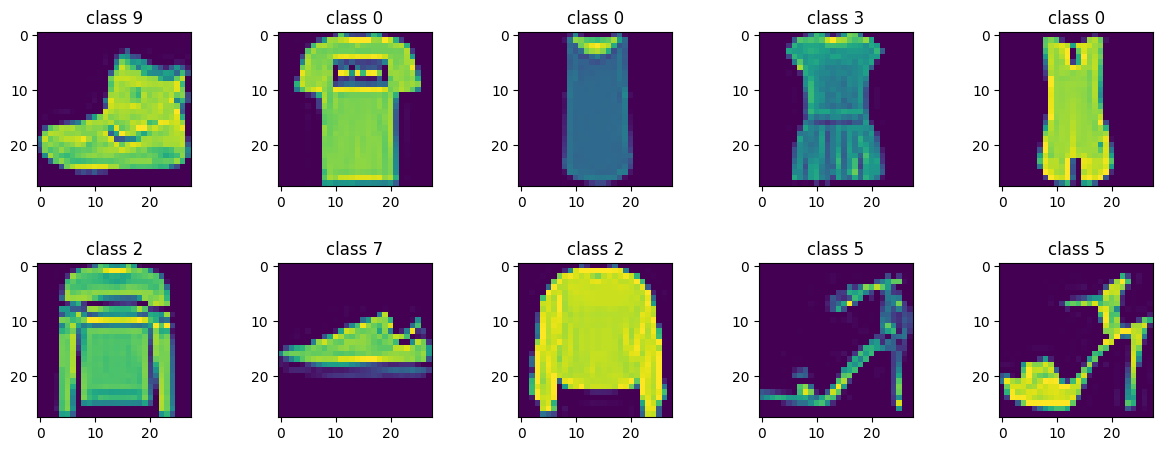

In [7]:
import matplotlib.pyplot as plt

# visualize
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].set_title('class ' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

Xay dung ANN

In [8]:
# innit
fashion_model = Sequential()

# hiddden layers
fashion_model.add(Dense(input_dim=X_train.shape[1],units=256,kernel_initializer='uniform',activation='relu'))

# output layers
fashion_model.add(Dense(units=10,kernel_initializer='uniform',activation='softmax'))

# compile
fashion_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# summary
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Huan luyen

In [9]:
model_fit = fashion_model.fit(X_train,y_train ,validation_split=0.1,epochs=20,verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8206 - loss: 0.5054 - val_accuracy: 0.8632 - val_loss: 0.3933
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8645 - loss: 0.3718 - val_accuracy: 0.8702 - val_loss: 0.3567
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8791 - loss: 0.3328 - val_accuracy: 0.8732 - val_loss: 0.3461
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8872 - loss: 0.3065 - val_accuracy: 0.8790 - val_loss: 0.3290
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8936 - loss: 0.2857 - val_accuracy: 0.8815 - val_loss: 0.3289
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8994 - loss: 0.2713 - val_accuracy: 0.8862 - val_loss: 0.3159
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9037 - loss: 0.2586 - val_accuracy: 0.8842 - val_loss: 0.3179
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9091 - loss: 0.246

Danh gia

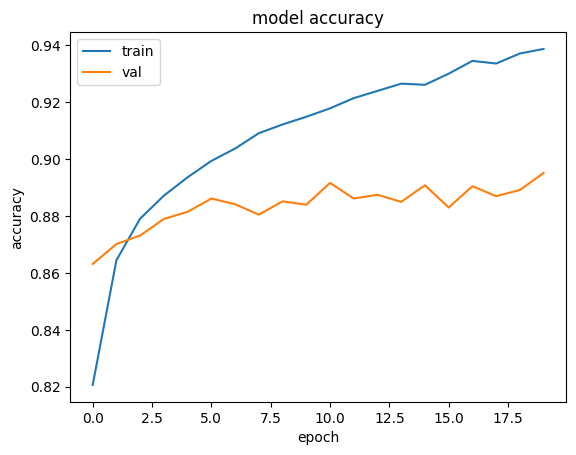

In [11]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','val'],loc='upper left')
plt.show()
#

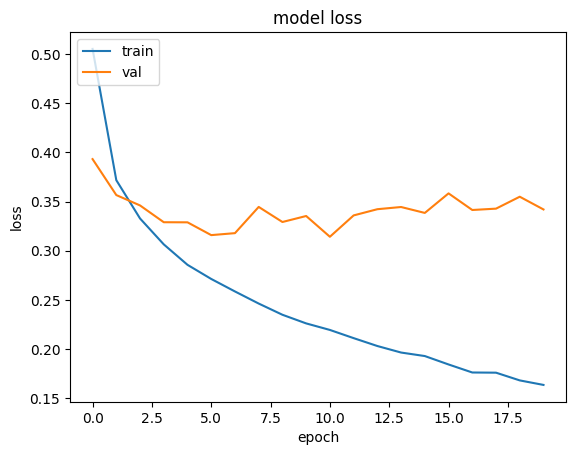

In [13]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','val'],loc='upper left')
plt.show()

Du doan

In [16]:
print(np.argmax(fashion_model.predict(X_test)[0]),y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]),y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
4 4


Doc du lieu tu file

In [21]:
mnist_train_path = '/content/sample_data/mnist_train_small.csv'
mist_test_path = '/content/sample_data/mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mist_test_path)
print(mnist_train.head())
print(mnist_train.shape)

   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(19999, 785)


In [22]:
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1],units=256,kernel_initializer='uniform',activation='relu'))
model.add(Dense(units=10,kernel_initializer='uniform',activation='softmax'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_fit= model.fit(X_train,y_train ,epochs=30,verbose=1)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8245 - loss: 0.4946
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8679 - loss: 0.3629
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8795 - loss: 0.3278
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8882 - loss: 0.3055
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8938 - loss: 0.2872
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9009 - loss: 0.2706
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9037 - loss: 0.2599
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9067 - loss: 0.2479
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9112 - loss: 0.2382
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9144 - loss: 0.2281
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9176 - loss: 0.2195
Epoch 12/30
1875/1875 ━━━━━

In [24]:
print(np.argmax(model.predict(X_test)[0]),y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9


In [26]:
img_size = (28,28)
img = tf.keras.preprocessing.image.load_img('/content/sample_data/1.jpg',color_mode='grayscale',target_size=img_size)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array,(784))
img_array = tf.expand_dims(img,0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
#
img_predict = model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)
#

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]
8


----------------------------BAI TAP



bai 1 : nhan dang anh tren dataset CIFAR-10

In [30]:
from tensorflow.keras.datasets import cifar10
# tai dataset
(X_train , y_train) , (X_test,y_test) = cifar10.load_data()
# chuan hoa
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0
# ANN
model_cifar10 = Sequential([
    # flatten
    Flatten(input_shape = (32,32,3)),
    # layer 1
    Dense(units=512,activation='relu'),
    #layer 2
    Dense(units=256,activation='relu'),
    # output layer
    Dense(units=10,activation='softmax'),
])
# model
model_cifar10.compile(
    optimizer='adam',
    loss ='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# train
model_cifar10.fit(X_train,y_train,epochs=20,batch_size=64,validation_split=0.1)
# test
test_loss,test_acc = model_cifar10.evaluate(X_test,y_test)
print('test accuracy:',test_acc)
# luu model
model_cifar10.save('model_cau1.h5')

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3188 - loss: 1.8988 - val_accuracy: 0.3656 - val_loss: 1.7861
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.3958 - loss: 1.6886 - val_accuracy: 0.3998 - val_loss: 1.6727
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4262 - loss: 1.6018 - val_accuracy: 0.4404 - val_loss: 1.5747
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.4500 - loss: 1.5436 - val_accuracy: 0.4574 - val_loss: 1.5236
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4648 - loss: 1.4944 - val_accuracy: 0.4372 - val_loss: 1.5577
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4749 - loss: 1.4674 - val_accuracy: 0.4578 - val_loss: 1.5456
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.4852 - loss: 1.4419 - val_accuracy: 0.4724 - val_loss: 1.4717
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.4970 - loss: 1.4122 - 

test accuracy: 0.5076000094413757


bai 2 : nhan dang chu so viet tay tren dataset MNIST

In [29]:
from tensorflow.keras.datasets import mnist

# tai data
(X_train,y_train),(X_test,y_test) = mnist.load_data()
# chuan hoa
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0
#  ANN
model_mnist = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(units=256,activation='relu'),
    Dense(units=128,activation='relu'),
    Dense(units=10,activation='softmax')
])
# model
model_mnist.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# train
model_mnist.fit(X_train,y_train,epochs=15,batch_size=64,validation_split=0.1)
# test
test_loss,test_acc = model_mnist.evaluate(X_test,y_test)
print('test accuracy:',test_acc)
#
# lưu file mô hình
model_mnist.save('model_cau2.h5')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9291 - loss: 0.2440 - val_accuracy: 0.9677 - val_loss: 0.1024
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9706 - loss: 0.0958 - val_accuracy: 0.9735 - val_loss: 0.0953
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9791 - loss: 0.0665 - val_accuracy: 0.9777 - val_loss: 0.0743
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9849 - loss: 0.0472 - val_accuracy: 0.9800 - val_loss: 0.0759
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9889 - loss: 0.0353 - val_accuracy: 0.9783 - val_loss: 0.0851
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9904 - loss: 0.0294 - val_accuracy: 0.9802 - val_loss: 0.0795
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9932 - loss: 0.0208 - val_accuracy: 0.9803 - val_loss: 0.0795
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9928 - loss: 0.0205 - val_accuracy: 0.

test accuracy: 0.9793000221252441


bai 3: nhan dang anh cho-meo

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Tải dữ liệu từ file .npy đã lưu
photos = np.load('dogs_vs_cats_photos.npy')
labels = np.load('dogs_vs_cats_labels.npy')

# 2. Chuẩn hóa dữ liệu pixel ảnh
photos = photos.astype('float32') / 255.0

# 3. Chia tập dữ liệu thành train (80%) và test (20%)
X_train, X_test, y_train, y_test = train_test_split(photos, labels, test_size=0.2, random_state=42)

# 4. Xây dựng mô hình ANN
model_cats_dogs = Sequential([
    Flatten(input_shape=(200, 200, 3)), # Ảnh đầu vào kích thước 200x200x3
    Dense(units=128, activation='relu'),
    Dense(units=64, activation='relu'),
    Dense(units=1, activation='sigmoid') # Phân loại nhị phân dùng Sigmoid
])

# 5. Biên dịch mô hình
model_cats_dogs.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Huấn luyện mô hình
model_cats_dogs.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))
# 7. Luu
model_cats_dogs.save('model_cau3.h5')
#

cau 4 :

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


# 1. Đọc dữ liệu
df = pd.read_csv('adult.csv')

# Xử lý các cột phân loại (Categorical columns) chuyển sang dạng số
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Tách Feature (X) và Label (y) - giả sử nhãn thu nhập nằm ở cột cuối cùng
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# 2. Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Chuẩn hóa đặc trưng dạng số (Bắt buộc đối với dữ liệu bảng khi chạy mạng ANN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Xây dựng mô hình ANN
model_adult = Sequential([
    Dense(units=64, input_dim=X_train.shape[1], activation='relu'),
    Dense(units=32, activation='relu'),
    Dense(units=1, activation='sigmoid') # Dự báo nhị phân >50K hoặc <=50K
])

# 5. Biên dịch và Huấn luyện
model_adult.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_adult.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))
# 6. luu
model_adult.save('model_cau4.h5')

cau 5

In [ ]:
from sklearn.preprocessing import LabelEncoder


# 1. Đọc dữ liệu
df_car = pd.read_csv('car.csv')

# Mã hóa dữ liệu chữ thành dữ liệu số
for column in df_car.columns:
    le = LabelEncoder()
    df_car[column] = le.fit_transform(df_car[column])

X = df_car.iloc[:, :-1].values
y = df_car.iloc[:, -1].values
num_classes = len(np.unique(y)) # Số lượng nhãn chất lượng xe

# 2. Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Xây dựng mô hình ANN
model_car = Sequential([
    Dense(units=32, input_dim=X_train.shape[1], activation='relu'),
    Dense(units=16, activation='relu'),
    Dense(units=num_classes, activation='softmax') # Phân loại đa lớp dùng Softmax
])

# 4. Biên dịch mô hình
model_car.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Huấn luyện
model_car.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test))
# 6. Luu
model_car.save('model_cau5.h5')